# First-Half Goals Model (Model Group 3)

Predicts **expected first-half goals for each side** with count models and derives
the first-half markets from a Dixon-Coles-adjusted half-score grid:

- 1H total goals over 0.5 / 1.5 (calibrated) and over 2.5 (reported uncalibrated -
  too few positives to fit a stable calibrator)
- 1H both teams to score, and 1H 1X2 as reported extras
- **Team to win either half**, derived from this 1H model plus a companion 2H
  model and cross-checked against the direct either-half classifiers stored by
  `1x2_pred.ipynb`

First halves behave differently from full matches (lower scoring, slower starts),
so the features are half-specific rolling form - 1H goals for/against, 1H shots
on target, 1H big chances and 1H xG - plus a slim full-time context (Elo, points
form, rest days). Second-half stats do not exist in the dataset; they are derived
as full-time minus half-time by `football_prediction.data.loading.load_matches`.

The model ladder and template mirror `goals_pred.ipynb`; shared pipeline code
comes from `src/football_prediction`.

## 1. Configuration

In [1]:
import warnings

import joblib
import numpy
import pandas
import matplotlib.pyplot as pyplot
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

from src.football_prediction.core import config
from src.football_prediction.data import loading as data
from src.football_prediction.features import rolling as features
from src.football_prediction.features import state
from src.football_prediction.features.elo import add_elo_features
from src.football_prediction.modeling import calibration, metrics
from src.football_prediction.markets import goals as markets

warnings.filterwarnings("ignore", category=FutureWarning)

artifact_path = config.MODELS_DIRECTORY / "first_half_goals_pred.joblib"
match_1x2_artifact_path = config.MODELS_DIRECTORY / "match_1x2_pred.joblib"

random_seed = config.RANDOM_SEED
# Half-goal grids are small, but lopsided cup fixtures can carry a 1H expected
# goals near 2.5-3, so 10 keeps the truncated tail negligible.
max_goals = 10
minimum_expected_goals = 0.02
maximum_expected_goals = 5.0

xgboost_parameters = {
    "n_estimators": 600,
    "learning_rate": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "early_stopping_rounds": 50,
    "n_jobs": -1,
    "random_state": random_seed,
}
max_depth_candidates = [3, 4, 5]
min_child_weight_candidates = [1, 5, 10]

# Half-specific raw columns. 1H shots on target are fully covered; 1H big
# chances (2024-2025 onward) and 1H xG (2023 onward) ride the NaN-tolerant path.
extra_raw_columns = [
    "home_shots_on_target_1h",
    "away_shots_on_target_1h",
    "home_big_chances_1h",
    "away_big_chances_1h",
    "home_expected_goals_1h",
    "away_expected_goals_1h",
]

own_metrics = {
    "goals_scored_1h": "{side}_score_ht",
    "goals_scored_2h": "{side}_score_2h",
    "points": "{side}_points",
    "shots_on_target_1h": "{side}_shots_on_target_1h",
    "big_chances_1h": "{side}_big_chances_1h",
    "expected_goals_for_1h": "{side}_expected_goals_1h",
}
opponent_metrics = {
    "goals_conceded_1h": "{side}_score_ht",
    "goals_conceded_2h": "{side}_score_2h",
    "shots_on_target_conceded_1h": "{side}_shots_on_target_1h",
    "expected_goals_against_1h": "{side}_expected_goals_1h",
}
short_rolling_metrics = [
    "goals_scored_1h",
    "goals_conceded_1h",
    "goals_scored_2h",
    "goals_conceded_2h",
    "shots_on_target_1h",
    "shots_on_target_conceded_1h",
    "points",
]
long_rolling_metrics = ["goals_scored_1h", "goals_conceded_1h"]
nan_tolerant_rolling_metrics = [
    "big_chances_1h",
    "expected_goals_for_1h",
    "expected_goals_against_1h",
]
venue_rolling_metrics = ["goals_scored_1h"]

core_feature_names = [
    "elo_difference",
    "home_elo",
    "away_elo",
    "home_1h_goals_scored_form",
    "away_1h_goals_scored_form",
    "home_1h_goals_conceded_form",
    "away_1h_goals_conceded_form",
    "home_long_1h_goals_scored_form",
    "away_long_1h_goals_scored_form",
    "home_long_1h_goals_conceded_form",
    "away_long_1h_goals_conceded_form",
    "home_1h_attack_vs_away_1h_defence",
    "away_1h_attack_vs_home_1h_defence",
    "home_1h_goals_at_home_form",
    "away_1h_goals_at_away_form",
    "home_1h_shots_on_target_form",
    "away_1h_shots_on_target_form",
    "home_1h_shots_on_target_conceded_form",
    "away_1h_shots_on_target_conceded_form",
    "points_form_difference",
    "rest_days_difference",
    "is_european_cup",
]
nan_tolerant_feature_names = [
    "home_1h_big_chances_form",
    "away_1h_big_chances_form",
    "home_1h_xg_for_form",
    "away_1h_xg_for_form",
    "home_1h_xg_against_form",
    "away_1h_xg_against_form",
]
feature_names = core_feature_names + nan_tolerant_feature_names

# Slim feature set for the companion 2H model (cross-check only).
second_half_feature_names = [
    "elo_difference",
    "home_elo",
    "away_elo",
    "home_2h_goals_scored_form",
    "away_2h_goals_scored_form",
    "home_2h_goals_conceded_form",
    "away_2h_goals_conceded_form",
    "points_form_difference",
    "rest_days_difference",
    "is_european_cup",
]

first_half_over_lines = [0.5, 1.5, 2.5]
calibrated_market_names = ["1h_over_0_5", "1h_over_1_5"]
decision_market_names = ["1h_over_0_5", "1h_over_1_5", "1h_under_0_5", "1h_under_1_5"]

pandas.set_option("display.max_columns", 80)
pandas.set_option("display.max_rows", 80)


## 2. Data loading and first-half base rates

In [2]:
matches, team_match_counts, team_filter_summary, load_summary = data.load_matches(
    extra_columns=extra_raw_columns,
)

# 2H scores are FT minus HT; a negative value would mean corrupted score data.
assert (matches["home_score_2h"] >= 0).all() and (matches["away_score_2h"] >= 0).all(), \
    "negative derived second-half scores"
print("Derived second-half scores are all non-negative")

print("\nCleaned dataset shape and date range")
print("Rows and columns:", matches.shape)
print("Date range:", matches["date_utc"].min().date(), "to", matches["date_utc"].max().date())

print("\nFirst-half market base rates over the whole cleaned dataset")
base_rate_records = {
    "mean_home_1h_goals": matches["home_score_ht"].mean(),
    "mean_away_1h_goals": matches["away_score_ht"].mean(),
    "mean_1h_total_goals": matches["first_half_total_goals"].mean(),
    "mean_2h_total_goals": (matches["home_score_2h"] + matches["away_score_2h"]).mean(),
}
for line in first_half_over_lines:
    base_rate_records[f"1h_over_{str(line).replace('.', '_')}_rate"] = (
        matches["first_half_total_goals"] > line
    ).mean()
base_rate_records["1h_btts_rate"] = (
    (matches["home_score_ht"] > 0) & (matches["away_score_ht"] > 0)
).mean()
display(pandas.DataFrame([base_rate_records]).round(3))

print("\nHalf-specific column coverage by season")
display(
    matches.assign(
        has_1h_shots_on_target=matches["home_shots_on_target_1h"].notna(),
        has_1h_big_chances=matches["home_big_chances_1h"].notna(),
        has_1h_expected_goals=matches["home_expected_goals_1h"].notna(),
    )
    .groupby("season")[["has_1h_shots_on_target", "has_1h_big_chances", "has_1h_expected_goals"]]
    .mean()
    .round(3)
)


Derived second-half scores are all non-negative

Cleaned dataset shape and date range
Rows and columns: (14721, 42)
Date range: 2020-08-18 to 2026-05-30

First-half market base rates over the whole cleaned dataset


,mean_home_1h_goals,mean_away_1h_goals,mean_1h_total_goals,mean_2h_total_goals,1h_over_0_5_rate,1h_over_1_5_rate,1h_over_2_5_rate,1h_btts_rate
0,0.699,0.559,1.259,1.559,0.714,0.358,0.136,0.202



Half-specific column coverage by season


,has_1h_shots_on_target,has_1h_big_chances,has_1h_expected_goals
season,,,
2020-2021,1.0,0.000,0.000
2021-2022,1.0,0.000,0.000
2022-2023,1.0,0.000,0.257
2023-2024,1.0,0.000,0.903
2024-2025,1.0,0.603,0.898
2025-2026,1.0,0.931,0.932


## 3. Half-specific feature table

Rolling form is computed on 1H (and 2H) metrics with the same leakage-safe
`closed="left"` machinery used everywhere else.

In [3]:
def build_first_half_feature_table(match_frame):
    matches_with_elo, final_team_ratings = add_elo_features(match_frame)
    team_match_rows = features.make_team_match_rows(
        matches_with_elo,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )
    rolling_team_form = features.add_rolling_team_form(
        team_match_rows,
        short_metrics=short_rolling_metrics,
        long_metrics=long_rolling_metrics,
        nan_tolerant_metrics=nan_tolerant_rolling_metrics,
        venue_metrics=venue_rolling_metrics,
    )
    form_columns = features.form_column_names(
        short_rolling_metrics,
        long_rolling_metrics,
        nan_tolerant_rolling_metrics,
        venue_rolling_metrics,
    )
    feature_table = features.merge_side_form(matches_with_elo, rolling_team_form, form_columns)

    feature_table["home_1h_goals_scored_form"] = feature_table["home_rolling_goals_scored_1h"]
    feature_table["away_1h_goals_scored_form"] = feature_table["away_rolling_goals_scored_1h"]
    feature_table["home_1h_goals_conceded_form"] = feature_table["home_rolling_goals_conceded_1h"]
    feature_table["away_1h_goals_conceded_form"] = feature_table["away_rolling_goals_conceded_1h"]
    feature_table["home_long_1h_goals_scored_form"] = feature_table["home_long_rolling_goals_scored_1h"]
    feature_table["away_long_1h_goals_scored_form"] = feature_table["away_long_rolling_goals_scored_1h"]
    feature_table["home_long_1h_goals_conceded_form"] = feature_table["home_long_rolling_goals_conceded_1h"]
    feature_table["away_long_1h_goals_conceded_form"] = feature_table["away_long_rolling_goals_conceded_1h"]
    feature_table["home_1h_attack_vs_away_1h_defence"] = (
        feature_table["home_rolling_goals_scored_1h"] - feature_table["away_rolling_goals_conceded_1h"]
    )
    feature_table["away_1h_attack_vs_home_1h_defence"] = (
        feature_table["away_rolling_goals_scored_1h"] - feature_table["home_rolling_goals_conceded_1h"]
    )
    feature_table["home_1h_goals_at_home_form"] = feature_table["home_rolling_goals_scored_1h_at_venue"]
    feature_table["away_1h_goals_at_away_form"] = feature_table["away_rolling_goals_scored_1h_at_venue"]
    feature_table["home_1h_shots_on_target_form"] = feature_table["home_rolling_shots_on_target_1h"]
    feature_table["away_1h_shots_on_target_form"] = feature_table["away_rolling_shots_on_target_1h"]
    feature_table["home_1h_shots_on_target_conceded_form"] = (
        feature_table["home_rolling_shots_on_target_conceded_1h"]
    )
    feature_table["away_1h_shots_on_target_conceded_form"] = (
        feature_table["away_rolling_shots_on_target_conceded_1h"]
    )
    feature_table["points_form_difference"] = (
        feature_table["home_rolling_points"] - feature_table["away_rolling_points"]
    )
    feature_table["rest_days_difference"] = (
        feature_table["home_rest_days"] - feature_table["away_rest_days"]
    )

    # 2H form for the companion second-half model.
    feature_table["home_2h_goals_scored_form"] = feature_table["home_rolling_goals_scored_2h"]
    feature_table["away_2h_goals_scored_form"] = feature_table["away_rolling_goals_scored_2h"]
    feature_table["home_2h_goals_conceded_form"] = feature_table["home_rolling_goals_conceded_2h"]
    feature_table["away_2h_goals_conceded_form"] = feature_table["away_rolling_goals_conceded_2h"]

    # NaN-tolerant half-specific chance creation.
    feature_table["home_1h_big_chances_form"] = feature_table["home_rolling_big_chances_1h"]
    feature_table["away_1h_big_chances_form"] = feature_table["away_rolling_big_chances_1h"]
    feature_table["home_1h_xg_for_form"] = feature_table["home_rolling_expected_goals_for_1h"]
    feature_table["away_1h_xg_for_form"] = feature_table["away_rolling_expected_goals_for_1h"]
    feature_table["home_1h_xg_against_form"] = feature_table["home_rolling_expected_goals_against_1h"]
    feature_table["away_1h_xg_against_form"] = feature_table["away_rolling_expected_goals_against_1h"]

    return feature_table, team_match_rows, rolling_team_form, final_team_ratings


feature_table, team_match_rows, rolling_team_form, final_team_ratings = (
    build_first_half_feature_table(matches)
)
model_data = feature_table.dropna(subset=core_feature_names).copy()

# Leakage spot-check on a half-specific metric.
example_team = rolling_team_form["team"].iloc[0]
example_history = rolling_team_form[rolling_team_form["team"].eq(example_team)].sort_values(
    ["date_utc", "match_id"]
)
check_position = 10
manual_mean = example_history["goals_scored_1h"].iloc[check_position - 5:check_position].mean()
assert abs(example_history["rolling_goals_scored_1h"].iloc[check_position] - manual_mean) < 1e-12
print(f"Leakage spot-check passed: rolling_goals_scored_1h for {example_team} equals "
      f"the mean of its previous 5 matches ({manual_mean:.3f})")

print("\nFeature build summary")
display(pandas.DataFrame([{
    "rows_before_dropping_no_history_rows": len(feature_table),
    "rows_after_dropping_no_history_rows": len(model_data),
    "rows_dropped": len(feature_table) - len(model_data),
    "core_features": len(core_feature_names),
    "missing_tolerant_features": len(nan_tolerant_feature_names),
    "total_features": len(feature_names),
}]))

print("\nMissing-tolerant feature availability (share of modelled rows with a value)")
display(
    model_data[nan_tolerant_feature_names].notna().mean().rename("available").round(3).to_frame()
)


Leakage spot-check passed: rolling_goals_scored_1h for linfield equals the mean of its previous 5 matches (0.000)

Feature build summary


,rows_before_dropping_no_history_rows,rows_after_dropping_no_history_rows,rows_dropped,core_features,missing_tolerant_features,total_features
0,14721,12475,2246,22,6,28



Missing-tolerant feature availability (share of modelled rows with a value)


,available
home_1h_big_chances_form,0.282
away_1h_big_chances_form,0.284
home_1h_xg_for_form,0.556
away_1h_xg_for_form,0.558
home_1h_xg_against_form,0.556
away_1h_xg_against_form,0.558


## 4. Temporal split (same dates as every other model group)

In [4]:
training_matches = model_data[model_data["date_utc"] < config.VALIDATION_SPLIT_DATE].copy()
validation_matches = model_data[
    (model_data["date_utc"] >= config.VALIDATION_SPLIT_DATE)
    & (model_data["date_utc"] < config.TEST_SPLIT_DATE)
].copy()
test_matches = model_data[model_data["date_utc"] >= config.TEST_SPLIT_DATE].copy()

split_summary = pandas.DataFrame([
    {
        "split": split_name,
        "rows": len(split_frame),
        "start": split_frame["date_utc"].min().date(),
        "end": split_frame["date_utc"].max().date(),
        "mean_home_1h_goals": split_frame["home_score_ht"].mean(),
        "mean_away_1h_goals": split_frame["away_score_ht"].mean(),
        "1h_over_0_5_rate": (split_frame["first_half_total_goals"] > 0.5).mean(),
        "1h_over_1_5_rate": (split_frame["first_half_total_goals"] > 1.5).mean(),
    }
    for split_name, split_frame in [
        ("training", training_matches),
        ("validation", validation_matches),
        ("test", test_matches),
    ]
])
print("Temporal three-way split summary")
print(f"Validation from {config.VALIDATION_SPLIT_DATE.date()}, test from {config.TEST_SPLIT_DATE.date()}")
display(split_summary.round(3))

training_feature_matrix = training_matches[feature_names]
validation_feature_matrix = validation_matches[feature_names]
test_feature_matrix = test_matches[feature_names]


Temporal three-way split summary
Validation from 2025-07-01, test from 2026-01-01


,split,rows,start,end,mean_home_1h_goals,mean_away_1h_goals,1h_over_0_5_rate,1h_over_1_5_rate
0,training,10072,2020-11-05,2025-05-31,0.701,0.568,0.719,0.360
1,validation,1251,2025-07-08,2025-12-30,0.671,0.537,0.694,0.345
2,test,1152,2026-01-01,2026-05-30,0.692,0.556,0.716,0.356


## 5. Baselines and XGBoost count models

Same ladder as the full-time goals notebook: constant league mean → Poisson GLM
on core features → XGBoost `count:poisson` per side with the validation sweep.

In [5]:
constant_home_mu = float(training_matches["home_score_ht"].mean())
constant_away_mu = float(training_matches["away_score_ht"].mean())
print(f"Constant baseline expected 1H goals: home {constant_home_mu:.3f}, away {constant_away_mu:.3f}")

poisson_glm_models = {}
for side_name, target_column in [("home", "home_score_ht"), ("away", "away_score_ht")]:
    glm_pipeline = make_pipeline(
        StandardScaler(),
        PoissonRegressor(alpha=1e-4, max_iter=500),
    )
    glm_pipeline.fit(training_matches[core_feature_names], training_matches[target_column])
    poisson_glm_models[side_name] = glm_pipeline


def fit_count_model(target_column, feature_columns, max_depth_value, min_child_weight_value):
    count_model = XGBRegressor(
        **xgboost_parameters,
        objective="count:poisson",
        eval_metric="poisson-nloglik",
        max_depth=max_depth_value,
        min_child_weight=min_child_weight_value,
    )
    count_model.fit(
        training_matches[feature_columns],
        training_matches[target_column],
        eval_set=[(validation_matches[feature_columns], validation_matches[target_column])],
        verbose=False,
    )
    return count_model


sweep_records = []
best_sweep_record = None
best_sweep_models = None
for max_depth_value in max_depth_candidates:
    for min_child_weight_value in min_child_weight_candidates:
        candidate_models = {
            "home": fit_count_model("home_score_ht", feature_names, max_depth_value, min_child_weight_value),
            "away": fit_count_model("away_score_ht", feature_names, max_depth_value, min_child_weight_value),
        }
        side_deviances = {}
        for side_name, target_column in [("home", "home_score_ht"), ("away", "away_score_ht")]:
            predicted_mu = numpy.clip(
                candidate_models[side_name].predict(validation_feature_matrix),
                minimum_expected_goals,
                maximum_expected_goals,
            )
            side_deviances[side_name] = metrics.count_metrics(
                validation_matches[target_column], predicted_mu
            )["poisson_deviance"]
        sweep_record = {
            "max_depth": max_depth_value,
            "min_child_weight": min_child_weight_value,
            "home_poisson_deviance": side_deviances["home"],
            "away_poisson_deviance": side_deviances["away"],
            "mean_poisson_deviance": (side_deviances["home"] + side_deviances["away"]) / 2.0,
        }
        sweep_records.append(sweep_record)
        if (
            best_sweep_record is None
            or sweep_record["mean_poisson_deviance"] < best_sweep_record["mean_poisson_deviance"]
        ):
            best_sweep_record = sweep_record
            best_sweep_models = candidate_models

sweep_table = pandas.DataFrame(sweep_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("\nValidation sweep (sorted by mean validation Poisson deviance)")
display(sweep_table.round(4))

best_max_depth = best_sweep_record["max_depth"]
best_min_child_weight = best_sweep_record["min_child_weight"]
xgboost_first_half_models = best_sweep_models
print(f"\nSelected configuration: max_depth={best_max_depth}, min_child_weight={best_min_child_weight}")


def expected_first_half_goals_for_family(family_name, split_frame):
    if family_name == "constant_league_mean":
        home_mu = numpy.full(len(split_frame), constant_home_mu)
        away_mu = numpy.full(len(split_frame), constant_away_mu)
    elif family_name == "poisson_glm":
        home_mu = poisson_glm_models["home"].predict(split_frame[core_feature_names])
        away_mu = poisson_glm_models["away"].predict(split_frame[core_feature_names])
    elif family_name == "xgboost_count_poisson":
        home_mu = xgboost_first_half_models["home"].predict(split_frame[feature_names])
        away_mu = xgboost_first_half_models["away"].predict(split_frame[feature_names])
    else:
        raise ValueError(f"Unknown model family {family_name!r}")
    return (
        numpy.clip(home_mu, minimum_expected_goals, maximum_expected_goals),
        numpy.clip(away_mu, minimum_expected_goals, maximum_expected_goals),
    )


family_records = []
for family_name in ["constant_league_mean", "poisson_glm", "xgboost_count_poisson"]:
    validation_home_mu, validation_away_mu = expected_first_half_goals_for_family(
        family_name, validation_matches,
    )
    home_metrics = metrics.count_metrics(validation_matches["home_score_ht"], validation_home_mu)
    away_metrics = metrics.count_metrics(validation_matches["away_score_ht"], validation_away_mu)
    family_records.append({
        "family": family_name,
        "home_mae": home_metrics["mae"],
        "away_mae": away_metrics["mae"],
        "home_poisson_deviance": home_metrics["poisson_deviance"],
        "away_poisson_deviance": away_metrics["poisson_deviance"],
        "mean_poisson_deviance": (home_metrics["poisson_deviance"] + away_metrics["poisson_deviance"]) / 2.0,
    })

family_table = pandas.DataFrame(family_records).sort_values("mean_poisson_deviance").reset_index(drop=True)
print("\nModel family comparison on the validation window")
display(family_table.round(4))

selected_model_family = family_table.iloc[0]["family"]
print(f"\nSelected model family: {selected_model_family}")


def predict_expected_first_half_goals(split_frame):
    return expected_first_half_goals_for_family(selected_model_family, split_frame)


Constant baseline expected 1H goals: home 0.701, away 0.568

Validation sweep (sorted by mean validation Poisson deviance)


,max_depth,min_child_weight,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,3,1,1.0353,1.0489,1.0421
1,3,10,1.0348,1.0498,1.0423
2,3,5,1.0357,1.0497,1.0427
3,4,5,1.0384,1.0529,1.0457
4,4,10,1.0369,1.0545,1.0457
5,4,1,1.0390,1.0538,1.0464
6,5,1,1.0413,1.0548,1.0481
7,5,10,1.0404,1.0562,1.0483
8,5,5,1.0410,1.0578,1.0494



Selected configuration: max_depth=3, min_child_weight=1

Model family comparison on the validation window


,family,home_mae,away_mae,home_poisson_deviance,away_poisson_deviance,mean_poisson_deviance
0,poisson_glm,0.6576,0.6271,1.0348,1.0470,1.0409
1,xgboost_count_poisson,0.6559,0.6268,1.0353,1.0489,1.0421
2,constant_league_mean,0.6914,0.6575,1.0976,1.1057,1.1016



Selected model family: poisson_glm


## 6. Dixon-Coles adjustment and half-score grids

Around 70% of half-scores live in the {0,1} x {0,1} corner, so the Dixon-Coles
adjustment matters more here than at full time.

In [6]:
training_home_mu, training_away_mu = predict_expected_first_half_goals(training_matches)
dixon_coles_rho = markets.fit_dixon_coles_rho(
    training_matches["home_score_ht"].to_numpy().astype(int),
    training_matches["away_score_ht"].to_numpy().astype(int),
    training_home_mu,
    training_away_mu,
)
print(f"Fitted Dixon-Coles rho on training 1H scores: {dixon_coles_rho:.4f}")


def build_split_grid(split_frame):
    home_mu, away_mu = predict_expected_first_half_goals(split_frame)
    return markets.build_score_grid(home_mu, away_mu, max_goals=max_goals, rho=dixon_coles_rho)


training_grid, training_mass = build_split_grid(training_matches)
validation_grid, validation_mass = build_split_grid(validation_matches)
test_grid, test_mass = build_split_grid(test_matches)

for split_name, grid, mass in [
    ("training", training_grid, training_mass),
    ("validation", validation_grid, validation_mass),
    ("test", test_grid, test_mass),
]:
    assert numpy.allclose(grid.sum(axis=(1, 2)), 1.0), f"{split_name} grid rows do not sum to 1"
    assert mass.min() >= 0.995, f"{split_name} pre-normalization mass too low: {mass.min():.6f}"
    print(f"{split_name}: grids sum to 1, minimum pre-normalization mass {mass.min():.6f}")


def derive_first_half_markets(grid):
    market_frame = pandas.DataFrame()
    for line in first_half_over_lines:
        market_frame[f"1h_over_{str(line).replace('.', '_')}"] = markets.grid_total_over(grid, line)
    market_frame["1h_btts_yes"] = markets.grid_btts(grid)
    grid_one_x_two = markets.grid_1x2(grid)
    market_frame["1h_home_win_probability"] = grid_one_x_two[:, 0]
    market_frame["1h_draw_probability"] = grid_one_x_two[:, 1]
    market_frame["1h_away_win_probability"] = grid_one_x_two[:, 2]
    return market_frame


def market_outcome(match_frame, market_name):
    if market_name.startswith("1h_over_"):
        line = float(market_name[len("1h_over_"):].replace("_", "."))
        return (match_frame["first_half_total_goals"] > line).astype(int)
    if market_name.startswith("1h_under_"):
        line = float(market_name[len("1h_under_"):].replace("_", "."))
        return (match_frame["first_half_total_goals"] < line).astype(int)
    if market_name == "1h_btts_yes":
        return ((match_frame["home_score_ht"] > 0) & (match_frame["away_score_ht"] > 0)).astype(int)
    raise ValueError(f"Unknown market {market_name!r}")


training_market_frame = derive_first_half_markets(training_grid)
validation_market_frame = derive_first_half_markets(validation_grid)
test_market_frame = derive_first_half_markets(test_grid)

sanity_records = []
for market_name in ["1h_over_0_5", "1h_over_1_5"]:
    mean_predicted = float(training_market_frame[market_name].mean())
    empirical_rate = float(market_outcome(training_matches, market_name).mean())
    sanity_records.append({
        "market": market_name,
        "mean_predicted_train": mean_predicted,
        "empirical_rate_train": empirical_rate,
        "gap": mean_predicted - empirical_rate,
    })
    assert abs(mean_predicted - empirical_rate) < 0.05, f"{market_name} calibration drift too large"
print("\nTraining-window sanity check: mean derived probability vs empirical rate")
display(pandas.DataFrame(sanity_records).round(4))


Fitted Dixon-Coles rho on training 1H scores: -0.0032
training: grids sum to 1, minimum pre-normalization mass 0.999951
validation: grids sum to 1, minimum pre-normalization mass 0.999997
test: grids sum to 1, minimum pre-normalization mass 0.999988

Training-window sanity check: mean derived probability vs empirical rate


,market,mean_predicted_train,empirical_rate_train,gap
0,1h_over_0_5,0.7161,0.7192,-0.0031
1,1h_over_1_5,0.3617,0.3604,0.0013


## 7. Market calibration

Over 0.5 and over 1.5 get Platt calibrators fitted on validation. Over 2.5 is
reported **uncalibrated**: only ~5% of matches clear it, far too few positives in
one validation season to fit a stable calibrator.

Validation market metrics (calibrators are in-sample here; 1h_over_2_5 and 1h_btts_yes stay raw by design)


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,1h_over_0_5 (raw),1251,0.6142,0.2116,0.7186,0.6938
1,1h_over_1_5 (raw),1251,0.6387,0.2233,0.3652,0.3445
2,1h_over_2_5 (raw),1251,0.3754,0.1094,0.1394,0.1255
3,1h_btts_yes (raw),1251,0.4811,0.1515,0.2025,0.1855
4,1h_over_0_5 (calibrated),1251,0.6127,0.2110,0.6939,0.6938
5,1h_over_1_5 (calibrated),1251,0.6377,0.2229,0.3446,0.3445


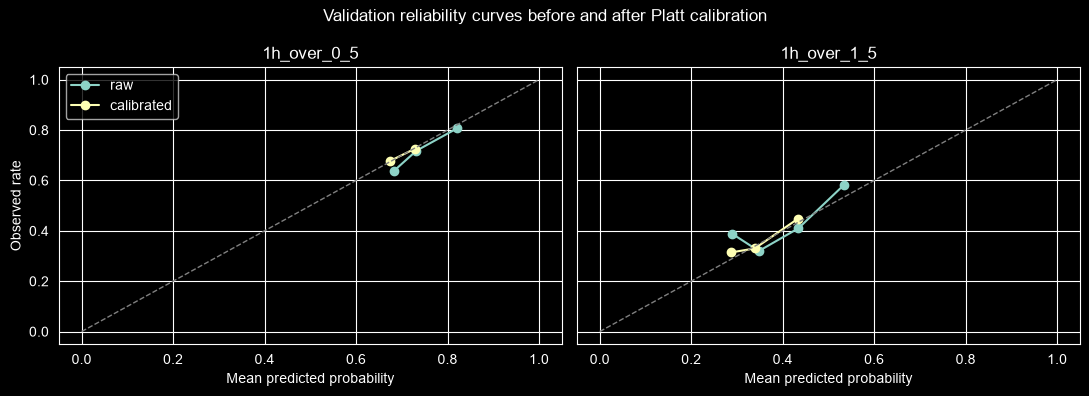

In [7]:
market_calibrators = {}
for market_name in calibrated_market_names:
    market_calibrators[market_name] = calibration.fit_binary_platt(
        validation_market_frame[market_name].to_numpy(),
        market_outcome(validation_matches, market_name).to_numpy(),
    )


def apply_market_calibration(market_frame):
    calibrated_frame = market_frame.copy()
    for market_name, market_calibrator in market_calibrators.items():
        calibrated_frame[market_name] = calibration.apply_binary_calibration(
            market_frame[market_name].to_numpy(), market_calibrator,
        )
    return calibrated_frame


validation_calibrated_market_frame = apply_market_calibration(validation_market_frame)

validation_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            validation_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names + ["1h_over_2_5", "1h_btts_yes"]
    },
    **{
        f"{market_name} (calibrated)": (
            validation_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(validation_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
})
print("Validation market metrics (calibrators are in-sample here; "
      "1h_over_2_5 and 1h_btts_yes stay raw by design)")
display(validation_market_eval.round(4))

figure, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for market_name, axis in zip(calibrated_market_names, axes):
    outcome_indicator = market_outcome(validation_matches, market_name).to_numpy().astype(float)
    for curve_label, probability_values in [
        ("raw", validation_market_frame[market_name].to_numpy()),
        ("calibrated", validation_calibrated_market_frame[market_name].to_numpy()),
    ]:
        curve_table = calibration.reliability_table(probability_values, outcome_indicator)
        axis.plot(curve_table["mean_predicted"], curve_table["observed_rate"], marker="o", label=curve_label)
    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axis.set_title(market_name)
    axis.set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed rate")
axes[0].legend()
figure.suptitle("Validation reliability curves before and after Platt calibration")
pyplot.tight_layout()
pyplot.show()


## 8. Companion 2H model and the derived win-either-half cross-check

A slim second-half XGBoost pair (same selected configuration) turns the two half
grids into `P(win either half) = 1 - (1 - P(win 1H)) x (1 - P(win 2H))` under an
independence assumption between halves. This derived probability is compared on
the shared test matches against the **direct** either-half classifiers stored in
the 1X2 artifact - a validation exercise, not a bettable product.

In [8]:
second_half_models = {
    "home": fit_count_model("home_score_2h", second_half_feature_names, best_max_depth, best_min_child_weight),
    "away": fit_count_model("away_score_2h", second_half_feature_names, best_max_depth, best_min_child_weight),
}


def predict_expected_second_half_goals(split_frame):
    home_mu = second_half_models["home"].predict(split_frame[second_half_feature_names])
    away_mu = second_half_models["away"].predict(split_frame[second_half_feature_names])
    return (
        numpy.clip(home_mu, minimum_expected_goals, maximum_expected_goals),
        numpy.clip(away_mu, minimum_expected_goals, maximum_expected_goals),
    )


second_half_rho = markets.fit_dixon_coles_rho(
    training_matches["home_score_2h"].to_numpy().astype(int),
    training_matches["away_score_2h"].to_numpy().astype(int),
    *predict_expected_second_half_goals(training_matches),
)
print(f"Fitted Dixon-Coles rho on training 2H scores: {second_half_rho:.4f}")


def derive_either_half_probabilities(split_frame, first_half_grid):
    first_half_one_x_two = markets.grid_1x2(first_half_grid)
    second_half_mu_home, second_half_mu_away = predict_expected_second_half_goals(split_frame)
    second_half_grid, _ = markets.build_score_grid(
        second_half_mu_home, second_half_mu_away, max_goals=max_goals, rho=second_half_rho,
    )
    second_half_one_x_two = markets.grid_1x2(second_half_grid)
    home_either_half = 1.0 - (1.0 - first_half_one_x_two[:, 0]) * (1.0 - second_half_one_x_two[:, 0])
    away_either_half = 1.0 - (1.0 - first_half_one_x_two[:, 2]) * (1.0 - second_half_one_x_two[:, 2])
    return home_either_half, away_either_half


test_home_either_half, test_away_either_half = derive_either_half_probabilities(
    test_matches, test_grid,
)

if match_1x2_artifact_path.exists():
    match_1x2_artifact = joblib.load(match_1x2_artifact_path)
    stored_either_half = match_1x2_artifact["test_evaluation_table"][[
        "date_utc", "home_team", "away_team",
        "home_wins_either_half_probability", "away_wins_either_half_probability",
    ]].copy()

    derived_either_half = test_matches[[
        "date_utc", "home_team", "away_team",
        "home_wins_either_half", "away_wins_either_half",
    ]].reset_index(drop=True).copy()
    derived_either_half["derived_home_probability"] = test_home_either_half
    derived_either_half["derived_away_probability"] = test_away_either_half

    shared_matches = stored_either_half.merge(
        derived_either_half, on=["date_utc", "home_team", "away_team"], how="inner",
    )
    either_half_comparison = metrics.market_eval_table({
        "home_wins_either_half (direct classifier)": (
            shared_matches["home_wins_either_half_probability"].to_numpy(),
            shared_matches["home_wins_either_half"].to_numpy(),
        ),
        "home_wins_either_half (derived from half grids)": (
            shared_matches["derived_home_probability"].to_numpy(),
            shared_matches["home_wins_either_half"].to_numpy(),
        ),
        "away_wins_either_half (direct classifier)": (
            shared_matches["away_wins_either_half_probability"].to_numpy(),
            shared_matches["away_wins_either_half"].to_numpy(),
        ),
        "away_wins_either_half (derived from half grids)": (
            shared_matches["derived_away_probability"].to_numpy(),
            shared_matches["away_wins_either_half"].to_numpy(),
        ),
    })
    print(f"Win-either-half on {len(shared_matches)} shared test matches "
          "(independence assumption between halves for the derived route)")
    display(either_half_comparison.round(4))
else:
    either_half_comparison = None
    print(f"Skipping either-half comparison: {match_1x2_artifact_path} not found. "
          "Run 1x2_pred.ipynb first to produce it.")


Fitted Dixon-Coles rho on training 2H scores: 0.0285
Win-either-half on 1152 shared test matches (independence assumption between halves for the derived route)


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,home_wins_either_half (direct classifier),1152,0.6357,0.2229,0.5999,0.5851
1,home_wins_either_half (derived from half grids),1152,0.6337,0.2220,0.5735,0.5851
2,away_wins_either_half (direct classifier),1152,0.6732,0.2390,0.4367,0.4583
3,away_wins_either_half (derived from half grids),1152,0.6644,0.2357,0.4671,0.4583


## 9. Decision layer and threshold tuning

Bets on 1H over/under 0.5 and 1.5 when the (calibrated) probability clears a
validation-tuned threshold: precision-max subject to a 15% coverage floor.

In [9]:
def decision_probability_frame(calibrated_market_frame):
    decision_frame = pandas.DataFrame(index=calibrated_market_frame.index)
    for market_name in decision_market_names:
        if market_name.startswith("1h_under_"):
            over_name = market_name.replace("1h_under_", "1h_over_")
            decision_frame[market_name] = 1.0 - calibrated_market_frame[over_name]
        else:
            decision_frame[market_name] = calibrated_market_frame[market_name]
    return decision_frame


threshold_candidates = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
minimum_pick_coverage = 0.15

validation_decision_probabilities = decision_probability_frame(validation_calibrated_market_frame)

threshold_tuning_records = []
decision_thresholds = {}
for market_name in decision_market_names:
    market_probabilities = validation_decision_probabilities[market_name].to_numpy()
    market_outcomes = market_outcome(validation_matches, market_name).to_numpy()
    market_rows = []
    for threshold in threshold_candidates:
        picked = market_probabilities >= threshold
        market_rows.append({
            "market": market_name,
            "threshold": threshold,
            "picks": int(picked.sum()),
            "coverage": float(picked.mean()),
            "precision": float(market_outcomes[picked].mean()) if picked.any() else numpy.nan,
        })
    market_tuning = pandas.DataFrame(market_rows)
    threshold_tuning_records.append(market_tuning)
    eligible = market_tuning[market_tuning["coverage"] >= minimum_pick_coverage]
    if eligible.empty:
        eligible = market_tuning[market_tuning["picks"] > 0]
    if eligible.empty:
        # No threshold ever picks a match; park the market at the strictest cut.
        decision_thresholds[market_name] = float(max(threshold_candidates))
    else:
        selected = eligible.sort_values(["precision", "coverage"], ascending=False).iloc[0]
        decision_thresholds[market_name] = float(selected["threshold"])

threshold_tuning_table = pandas.concat(threshold_tuning_records, ignore_index=True)


def summarize_market_decisions(decision_probabilities, match_frame, thresholds):
    summary_records = []
    total_picks = 0
    total_wins = 0.0
    for market_name in decision_market_names:
        picked = decision_probabilities[market_name].to_numpy() >= thresholds[market_name]
        outcomes = market_outcome(match_frame, market_name).to_numpy()
        picks = int(picked.sum())
        wins = float(outcomes[picked].sum()) if picks else 0.0
        total_picks += picks
        total_wins += wins
        summary_records.append({
            "market": market_name,
            "threshold": thresholds[market_name],
            "picks": picks,
            "coverage": float(picked.mean()),
            "precision": wins / picks if picks else numpy.nan,
        })
    summary_records.append({
        "market": "combined slate",
        "threshold": numpy.nan,
        "picks": total_picks,
        "coverage": numpy.nan,
        "precision": total_wins / total_picks if total_picks else numpy.nan,
    })
    return pandas.DataFrame(summary_records)


print("Selected thresholds per market (validation precision-max, coverage floor "
      f"{minimum_pick_coverage:.0%})")
validation_decision_summary = summarize_market_decisions(
    validation_decision_probabilities, validation_matches, decision_thresholds,
)
display(validation_decision_summary.round(3))


Selected thresholds per market (validation precision-max, coverage floor 15%)


,market,threshold,picks,coverage,precision
0,1h_over_0_5,0.7,439,0.351,0.724
1,1h_over_1_5,0.9,0,0.000,NaN
2,1h_under_0_5,0.9,0,0.000,NaN
3,1h_under_1_5,0.7,191,0.153,0.686
4,combined slate,NaN,630,NaN,0.713


## 10. Final test evaluation

In [10]:
test_calibrated_market_frame = apply_market_calibration(test_market_frame)

test_market_eval = metrics.market_eval_table({
    **{
        f"{market_name} (raw)": (
            test_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names + ["1h_over_2_5", "1h_btts_yes"]
    },
    **{
        f"{market_name} (calibrated)": (
            test_calibrated_market_frame[market_name].to_numpy(),
            market_outcome(test_matches, market_name).to_numpy(),
        )
        for market_name in calibrated_market_names
    },
})
print("Test market metrics")
display(test_market_eval.round(4))

# 1H 1X2 extra: grid-derived vs the training class-frequency baseline.
first_half_result = numpy.where(
    test_matches["home_score_ht"] > test_matches["away_score_ht"], 0,
    numpy.where(test_matches["away_score_ht"] > test_matches["home_score_ht"], 2, 1),
)
training_first_half_rates = numpy.array([
    (training_matches["home_score_ht"] > training_matches["away_score_ht"]).mean(),
    (training_matches["home_score_ht"] == training_matches["away_score_ht"]).mean(),
    (training_matches["away_score_ht"] > training_matches["home_score_ht"]).mean(),
])
first_half_one_x_two_comparison = pandas.DataFrame([
    {
        "model": "1h class frequency",
        **metrics.evaluate_multiclass_probabilities(
            first_half_result,
            numpy.tile(training_first_half_rates, (len(test_matches), 1)),
        ),
    },
    {
        "model": "1h grid derived",
        **metrics.evaluate_multiclass_probabilities(
            first_half_result,
            test_market_frame[[
                "1h_home_win_probability", "1h_draw_probability", "1h_away_win_probability",
            ]].to_numpy(),
        ),
    },
])
print("\n1H 1X2 on the test window (reported extra)")
display(first_half_one_x_two_comparison.round(4))

test_decision_probabilities = decision_probability_frame(test_calibrated_market_frame)
test_decision_summary = summarize_market_decisions(
    test_decision_probabilities, test_matches, decision_thresholds,
)
print("\nDecision summary on the test set (tuned thresholds)")
display(test_decision_summary.round(3))


Test market metrics


,market,rows,log_loss,brier,mean_predicted,empirical_rate
0,1h_over_0_5 (raw),1152,0.5907,0.2010,0.7231,0.7161
1,1h_over_1_5 (raw),1152,0.6446,0.2263,0.3716,0.3559
2,1h_over_2_5 (raw),1152,0.3718,0.1079,0.1440,0.1233
3,1h_btts_yes (raw),1152,0.4855,0.1538,0.2028,0.1910
4,1h_over_0_5 (calibrated),1152,0.5917,0.2014,0.6980,0.7161
5,1h_over_1_5 (calibrated),1152,0.6441,0.2261,0.3510,0.3559



1H 1X2 on the test window (reported extra)


,model,accuracy,log_loss
0,1h class frequency,0.3924,1.0858
1,1h grid derived,0.4375,1.0556



Decision summary on the test set (tuned thresholds)


,market,threshold,picks,coverage,precision
0,1h_over_0_5,0.7,466,0.405,0.775
1,1h_over_1_5,0.9,0,0.000,NaN
2,1h_under_0_5,0.9,0,0.000,NaN
3,1h_under_1_5,0.7,187,0.162,0.684
4,combined slate,NaN,653,NaN,0.749


## 11. Team-state store and fixture prediction

In [11]:
trained_team_names = sorted(
    set(training_matches["home_team"]).union(training_matches["away_team"])
)


def build_first_half_team_state_store(results_frame):
    return state.build_team_state_store(
        results_frame,
        own_metrics=own_metrics,
        opponent_metrics=opponent_metrics,
        ratio_metrics={},
    )


def build_first_half_fixture_features(home_team, away_team, date, time="15:00",
                                      european_cup=False, team_state_store=None):
    state.validate_known_teams(home_team, away_team, trained_team_names)
    if team_state_store is None:
        team_state_store = build_first_half_team_state_store(matches)

    fixture_date = pandas.to_datetime(f"{date} {time}", errors="coerce")
    if pandas.isna(fixture_date):
        fixture_date = pandas.to_datetime(date)

    elo_ratings = team_state_store["team_elo_ratings"]
    missing_elo_team_names = [
        team_name for team_name in [home_team, away_team] if team_name not in elo_ratings
    ]
    if missing_elo_team_names:
        raise ValueError(
            "Cannot build Elo features without stored ratings for: "
            + ", ".join(missing_elo_team_names)
        )
    home_elo = float(elo_ratings[home_team])
    away_elo = float(elo_ratings[away_team])

    def short_form(team_name, metric_name):
        return state.state_mean(team_state_store, team_name, "recent_matches", metric_name)

    def long_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.LONG_WINDOW, minimum_matches=config.LONG_WINDOW_MINIMUM_MATCHES,
        )

    def nan_tolerant_form(team_name, metric_name):
        return state.state_mean(
            team_state_store, team_name, "recent_matches", metric_name,
            window=config.XG_WINDOW, minimum_matches=config.XG_WINDOW_MINIMUM_MATCHES,
            required=False,
        )

    fixture_feature_values = {
        "elo_difference": home_elo - away_elo,
        "home_elo": home_elo,
        "away_elo": away_elo,
        "home_1h_goals_scored_form": short_form(home_team, "goals_scored_1h"),
        "away_1h_goals_scored_form": short_form(away_team, "goals_scored_1h"),
        "home_1h_goals_conceded_form": short_form(home_team, "goals_conceded_1h"),
        "away_1h_goals_conceded_form": short_form(away_team, "goals_conceded_1h"),
        "home_long_1h_goals_scored_form": long_form(home_team, "goals_scored_1h"),
        "away_long_1h_goals_scored_form": long_form(away_team, "goals_scored_1h"),
        "home_long_1h_goals_conceded_form": long_form(home_team, "goals_conceded_1h"),
        "away_long_1h_goals_conceded_form": long_form(away_team, "goals_conceded_1h"),
        "home_1h_attack_vs_away_1h_defence": (
            short_form(home_team, "goals_scored_1h") - short_form(away_team, "goals_conceded_1h")
        ),
        "away_1h_attack_vs_home_1h_defence": (
            short_form(away_team, "goals_scored_1h") - short_form(home_team, "goals_conceded_1h")
        ),
        "home_1h_goals_at_home_form": state.state_mean(
            team_state_store, home_team, "recent_home_matches", "goals_scored_1h",
        ),
        "away_1h_goals_at_away_form": state.state_mean(
            team_state_store, away_team, "recent_away_matches", "goals_scored_1h",
        ),
        "home_1h_shots_on_target_form": short_form(home_team, "shots_on_target_1h"),
        "away_1h_shots_on_target_form": short_form(away_team, "shots_on_target_1h"),
        "home_1h_shots_on_target_conceded_form": short_form(home_team, "shots_on_target_conceded_1h"),
        "away_1h_shots_on_target_conceded_form": short_form(away_team, "shots_on_target_conceded_1h"),
        "points_form_difference": short_form(home_team, "points") - short_form(away_team, "points"),
        "rest_days_difference": (
            state.state_rest_days(team_state_store, home_team, fixture_date)
            - state.state_rest_days(team_state_store, away_team, fixture_date)
        ),
        "is_european_cup": int(european_cup),
        "home_1h_big_chances_form": nan_tolerant_form(home_team, "big_chances_1h"),
        "away_1h_big_chances_form": nan_tolerant_form(away_team, "big_chances_1h"),
        "home_1h_xg_for_form": nan_tolerant_form(home_team, "expected_goals_for_1h"),
        "away_1h_xg_for_form": nan_tolerant_form(away_team, "expected_goals_for_1h"),
        "home_1h_xg_against_form": nan_tolerant_form(home_team, "expected_goals_against_1h"),
        "away_1h_xg_against_form": nan_tolerant_form(away_team, "expected_goals_against_1h"),
        "home_2h_goals_scored_form": short_form(home_team, "goals_scored_2h"),
        "away_2h_goals_scored_form": short_form(away_team, "goals_scored_2h"),
        "home_2h_goals_conceded_form": short_form(home_team, "goals_conceded_2h"),
        "away_2h_goals_conceded_form": short_form(away_team, "goals_conceded_2h"),
    }
    fixture_frame = pandas.DataFrame([fixture_feature_values])
    return fixture_frame[feature_names + [
        "home_2h_goals_scored_form",
        "away_2h_goals_scored_form",
        "home_2h_goals_conceded_form",
        "away_2h_goals_conceded_form",
    ]]


def predict_fixture(home_team, away_team, date, time="15:00", european_cup=False,
                    team_state_store=None):
    fixture_features = build_first_half_fixture_features(
        home_team, away_team, date, time=time,
        european_cup=european_cup, team_state_store=team_state_store,
    )
    home_mu, away_mu = predict_expected_first_half_goals(fixture_features)
    fixture_grid, _ = markets.build_score_grid(
        home_mu, away_mu, max_goals=max_goals, rho=dixon_coles_rho,
    )
    fixture_markets = apply_market_calibration(derive_first_half_markets(fixture_grid))
    fixture_decisions = decision_probability_frame(fixture_markets)
    picked_markets = [
        market_name
        for market_name in decision_market_names
        if float(fixture_decisions[market_name].iloc[0]) >= decision_thresholds[market_name]
    ]
    home_either_half, away_either_half = derive_either_half_probabilities(
        fixture_features, fixture_grid,
    )
    top_scorelines = markets.grid_exact_scores(fixture_grid, top_k=3)[0]

    prediction_record = {
        "date": pandas.to_datetime(date).date(),
        "time": time,
        "home_team": home_team,
        "away_team": away_team,
        "expected_home_1h_goals": float(home_mu[0]),
        "expected_away_1h_goals": float(away_mu[0]),
        "expected_1h_total_goals": float(home_mu[0] + away_mu[0]),
        "top_1h_scorelines": ", ".join(f"{s} ({p:.2f})" for s, p in top_scorelines),
        "derived_home_wins_either_half": float(home_either_half[0]),
        "derived_away_wins_either_half": float(away_either_half[0]),
        "decision": ", ".join(picked_markets) if picked_markets else "skip",
    }
    for market_name in ["1h_over_0_5", "1h_over_1_5", "1h_over_2_5", "1h_btts_yes",
                        "1h_home_win_probability", "1h_draw_probability", "1h_away_win_probability"]:
        prediction_record[market_name] = float(fixture_markets[market_name].iloc[0])
    return pandas.DataFrame([prediction_record])


predict_fixture("lens", "lyon", "2026-08-15")


,date,time,home_team,away_team,expected_home_1h_goals,expected_away_1h_goals,expected_1h_total_goals,top_1h_scorelines,derived_home_wins_either_half,derived_away_wins_either_half,decision,1h_over_0_5,1h_over_1_5,1h_over_2_5,1h_btts_yes,1h_home_win_probability,1h_draw_probability,1h_away_win_probability
0,2026-08-15,15:00,lens,lyon,0.784075,0.548189,1.332264,"0-0 (0.26), 1-0 (0.21), 0-1 (0.14)",0.619811,0.434532,1h_over_0_5,0.708608,0.363754,0.150381,0.2297,0.376592,0.390803,0.232605


## 12. Historical fixture demo with feature reproduction check

In [12]:
demo_candidate_fixtures = matches[matches["date_utc"] >= config.TEST_SPLIT_DATE].head(10)
demo_predictions = []
feature_reproduction_checked = False
model_data_match_ids = set(model_data["match_id"])

for fixture_record in demo_candidate_fixtures.itertuples(index=False):
    if len(demo_predictions) == 5:
        break
    try:
        state_before_fixture = build_first_half_team_state_store(
            matches[matches["date_utc"] < fixture_record.date_utc]
        )
        if not feature_reproduction_checked and fixture_record.match_id in model_data_match_ids:
            rebuilt_features = build_first_half_fixture_features(
                fixture_record.home_team,
                fixture_record.away_team,
                fixture_record.date_utc.strftime("%Y-%m-%d"),
                fixture_record.date_utc.strftime("%H:%M"),
                european_cup=bool(fixture_record.is_european_cup),
                team_state_store=state_before_fixture,
            )
            stored_features = model_data.loc[
                model_data["match_id"].eq(fixture_record.match_id), feature_names
            ].iloc[0].to_numpy(dtype=float)
            assert numpy.allclose(
                rebuilt_features[feature_names].iloc[0].to_numpy(dtype=float),
                stored_features,
                atol=1e-8,
                equal_nan=True,
            ), "fixture features do not reproduce the training feature row"
            print(f"Feature reproduction check passed for {fixture_record.home_team} vs "
                  f"{fixture_record.away_team} ({fixture_record.date_utc.date()})")
            feature_reproduction_checked = True
        prediction = predict_fixture(
            fixture_record.home_team,
            fixture_record.away_team,
            fixture_record.date_utc.strftime("%Y-%m-%d"),
            fixture_record.date_utc.strftime("%H:%M"),
            european_cup=bool(fixture_record.is_european_cup),
            team_state_store=state_before_fixture,
        )
    except ValueError as fixture_error:
        print(f"Skipping {fixture_record.home_team} vs {fixture_record.away_team}: {fixture_error}")
        continue
    prediction["competition"] = fixture_record.competition
    prediction["actual_1h_score"] = (
        f"{int(fixture_record.home_score_ht)}-{int(fixture_record.away_score_ht)}"
    )
    prediction["actual_1h_total_goals"] = int(fixture_record.first_half_total_goals)
    prediction["actual_home_wins_either_half"] = bool(fixture_record.home_wins_either_half)
    prediction["actual_away_wins_either_half"] = bool(fixture_record.away_wins_either_half)
    demo_predictions.append(prediction)

historical_fixture_demo = (
    pandas.concat(demo_predictions, ignore_index=True)
    if demo_predictions
    else pandas.DataFrame()
)
print("\nHistorical fixture prediction demo")
display(historical_fixture_demo)


Feature reproduction check passed for crystal_palace vs fulham (2026-01-01)
Skipping sunderland vs manchester_city: Cannot predict fixtures for team names that were not present in training data: sunderland

Historical fixture prediction demo


,date,time,home_team,away_team,expected_home_1h_goals,expected_away_1h_goals,expected_1h_total_goals,top_1h_scorelines,derived_home_wins_either_half,derived_away_wins_either_half,decision,1h_over_0_5,1h_over_1_5,1h_over_2_5,1h_btts_yes,1h_home_win_probability,1h_draw_probability,1h_away_win_probability,competition,actual_1h_score,actual_1h_total_goals,actual_home_wins_either_half,actual_away_wins_either_half
0,2026-01-01,17:30,crystal_palace,fulham,0.776704,0.479514,1.256218,"0-0 (0.29), 1-0 (0.22), 0-1 (0.14)",0.632994,0.419149,skip,0.690335,0.337284,0.132927,0.206060,0.391540,0.401736,0.206724,Premier League,1-0,1,True,True
1,2026-01-01,17:30,liverpool,leeds,1.142911,0.312727,1.455638,"1-0 (0.27), 0-0 (0.23), 2-0 (0.15)",0.821873,0.225117,1h_over_0_5,0.736024,0.405752,0.180103,0.183176,0.574352,0.324899,0.100749,Premier League,0-0,0,False,False
2,2026-01-01,20:00,brentford,tottenham,0.633185,0.526832,1.160017,"0-0 (0.31), 1-0 (0.20), 0-1 (0.16)",0.543965,0.481771,skip,0.665452,0.303441,0.111960,0.192440,0.320250,0.427764,0.251986,Premier League,0-0,0,False,False
3,2026-01-02,19:45,toulouse,lens,0.557663,0.709381,1.267043,"0-0 (0.28), 0-1 (0.20), 1-0 (0.16)",0.460004,0.577728,skip,0.692996,0.341085,0.135367,0.217521,0.250128,0.405308,0.344564,Ligue 1,0-0,0,False,True
4,2026-01-02,19:45,cagliari,ac_milan,0.414913,0.818620,1.233533,"0-0 (0.29), 0-1 (0.24), 1-0 (0.12)",0.329071,0.701267,skip,0.684667,0.329315,0.127865,0.190137,0.174477,0.399540,0.425983,Serie A,0-0,0,False,True


## 13. Save the model artifact

In [13]:
team_state_store = build_first_half_team_state_store(matches)

selected_first_half_models = {
    "constant_league_mean": {"home": constant_home_mu, "away": constant_away_mu},
    "poisson_glm": poisson_glm_models,
    "xgboost_count_poisson": xgboost_first_half_models,
}[selected_model_family]

artifact = {
    "half": "1h",
    "model_family": selected_model_family,
    "model_setup": "per-side first-half goal count models with a Dixon-Coles-adjusted "
                   "half-score grid; 1H markets derived from the grid, plus a companion "
                   "2H model for the derived win-either-half cross-check",
    "first_half_models": selected_first_half_models,
    "second_half_models": second_half_models,
    "xgboost_parameters": xgboost_parameters,
    "selected_max_depth": best_max_depth,
    "selected_min_child_weight": best_min_child_weight,
    "dixon_coles_rho_1h": dixon_coles_rho,
    "dixon_coles_rho_2h": second_half_rho,
    "max_goals": max_goals,
    "minimum_expected_goals": minimum_expected_goals,
    "maximum_expected_goals": maximum_expected_goals,
    "market_calibrators": market_calibrators,
    "calibrated_market_names": calibrated_market_names,
    "decision_market_names": decision_market_names,
    "decision_thresholds": decision_thresholds,
    "feature_names": feature_names,
    "core_feature_names": core_feature_names,
    "nan_tolerant_feature_names": nan_tolerant_feature_names,
    "second_half_feature_names": second_half_feature_names,
    "own_metrics": own_metrics,
    "opponent_metrics": opponent_metrics,
    "first_half_over_lines": first_half_over_lines,
    "short_window": config.SHORT_WINDOW,
    "long_window": config.LONG_WINDOW,
    "long_window_minimum_matches": config.LONG_WINDOW_MINIMUM_MATCHES,
    "nan_tolerant_window": config.XG_WINDOW,
    "nan_tolerant_window_minimum_matches": config.XG_WINDOW_MINIMUM_MATCHES,
    "minimum_team_matches": config.MINIMUM_TEAM_MATCHES,
    "maximum_rest_days": config.MAXIMUM_REST_DAYS,
    "initial_elo": config.INITIAL_ELO,
    "elo_k": config.ELO_K,
    "home_advantage": config.HOME_ADVANTAGE,
    "european_cup_names": config.EUROPEAN_CUP_NAMES,
    "validation_split_date": config.VALIDATION_SPLIT_DATE,
    "test_split_date": config.TEST_SPLIT_DATE,
    "trained_team_names": trained_team_names,
    "team_state_store": team_state_store,
    "sweep_table": sweep_table,
    "family_table": family_table,
    "validation_market_eval": validation_market_eval,
    "test_market_eval": test_market_eval,
    "first_half_one_x_two_comparison": first_half_one_x_two_comparison,
    "either_half_comparison": either_half_comparison,
    "threshold_tuning_table": threshold_tuning_table,
    "validation_decision_summary": validation_decision_summary,
    "test_decision_summary": test_decision_summary,
    "team_filter_summary": team_filter_summary,
    "load_summary": load_summary,
    "data_path": str(config.DATA_PATH),
}

config.MODELS_DIRECTORY.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, artifact_path)
reloaded_artifact = joblib.load(artifact_path)

sample_features = test_matches[feature_names].head(5)
in_memory_home_mu, in_memory_away_mu = predict_expected_first_half_goals(sample_features)
if selected_model_family == "xgboost_count_poisson":
    reloaded_home_mu = numpy.clip(
        reloaded_artifact["first_half_models"]["home"].predict(sample_features),
        minimum_expected_goals, maximum_expected_goals,
    )
    reloaded_away_mu = numpy.clip(
        reloaded_artifact["first_half_models"]["away"].predict(sample_features),
        minimum_expected_goals, maximum_expected_goals,
    )
elif selected_model_family == "poisson_glm":
    reloaded_home_mu = numpy.clip(
        reloaded_artifact["first_half_models"]["home"].predict(sample_features[core_feature_names]),
        minimum_expected_goals, maximum_expected_goals,
    )
    reloaded_away_mu = numpy.clip(
        reloaded_artifact["first_half_models"]["away"].predict(sample_features[core_feature_names]),
        minimum_expected_goals, maximum_expected_goals,
    )
else:
    reloaded_home_mu = numpy.full(len(sample_features), reloaded_artifact["first_half_models"]["home"])
    reloaded_away_mu = numpy.full(len(sample_features), reloaded_artifact["first_half_models"]["away"])
assert numpy.allclose(in_memory_home_mu, reloaded_home_mu)
assert numpy.allclose(in_memory_away_mu, reloaded_away_mu)
print("Round-trip check passed: reloaded models reproduce in-memory expected 1H goals")

print(f"\nSaved artifact to {artifact_path}")
print("Reloaded artifact keys:", sorted(reloaded_artifact.keys()))
print("Reloaded model family:", reloaded_artifact["model_family"])
print("Reloaded decision thresholds:", reloaded_artifact["decision_thresholds"])


Round-trip check passed: reloaded models reproduce in-memory expected 1H goals

Saved artifact to C:\PROJECTS\Python\ML\betting\models\first_half_goals_pred.joblib
Reloaded artifact keys: ['calibrated_market_names', 'core_feature_names', 'data_path', 'decision_market_names', 'decision_thresholds', 'dixon_coles_rho_1h', 'dixon_coles_rho_2h', 'either_half_comparison', 'elo_k', 'european_cup_names', 'family_table', 'feature_names', 'first_half_models', 'first_half_one_x_two_comparison', 'first_half_over_lines', 'half', 'home_advantage', 'initial_elo', 'load_summary', 'long_window', 'long_window_minimum_matches', 'market_calibrators', 'max_goals', 'maximum_expected_goals', 'maximum_rest_days', 'minimum_expected_goals', 'minimum_team_matches', 'model_family', 'model_setup', 'nan_tolerant_feature_names', 'nan_tolerant_window', 'nan_tolerant_window_minimum_matches', 'opponent_metrics', 'own_metrics', 'second_half_feature_names', 'second_half_models', 'selected_max_depth', 'selected_min_child_